I want to implement embedding example


%pip install  torch transformers
from transformers import BertTokenizer,BertModel
import torch
from bertviz.transformers_neuron_view import BertModel, BertTokenizer
from bertviz.neuron_view import show
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

model = BertModel.from_pretrained('bert-base-uncased')

text = "Here is the sentence i want embedding for"
encoded_input = tokenizer(text,return_tensors='pt')

with torch.no_grad():
    model_output = model(**encoded_input)

    sentence_embeddings = torch.mean(model_output.last_hidden_state,dim=1)
    print("sentence_embedding: ",sentence_embeddings)

    show(
    model,
    model_type,
    tokenizer,
    sentence_a,
    layer=4,
    head=3
)

In [2]:
%pip install torch transformers bertviz

import torch
from transformers import BertTokenizer, BertModel
from bertviz import head_view

# -----------------------------
# 1. Load BERT
# -----------------------------

model_name = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(model_name)

model = BertModel.from_pretrained(
    model_name,
    output_attentions=True
)

# -----------------------------
# 2. Input sentence
# -----------------------------

sentence_a = "Here is the sentence I want embedding for"

encoded_input = tokenizer(
    sentence_a,
    return_tensors="pt"
)

# -----------------------------
# 3. Run BERT
# -----------------------------

with torch.no_grad():
    model_output = model(**encoded_input)

# -----------------------------
# 4. Sentence embedding
# -----------------------------

token_embeddings = model_output.last_hidden_state

sentence_embedding = torch.mean(
    token_embeddings,
    dim=1
)

print("Sentence embedding shape:")
print(sentence_embedding.shape)

print("\nSentence embedding:")
print(sentence_embedding)

# -----------------------------
# 5. Get attention weights
# -----------------------------

attention = model_output.attentions

# Convert token IDs → tokens
tokens = tokenizer.convert_ids_to_tokens(
    encoded_input["input_ids"][0]
)

print("\nTokens:")
print(tokens)

# -----------------------------
# 6. Visualize attention
# -----------------------------

head_view(
    attention,
    tokens,
    layer=4,
    heads=[3]
)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence embedding shape:
torch.Size([1, 768])

Sentence embedding:
tensor([[ 1.7904e-01, -2.5153e-01,  1.7983e-01,  3.8165e-02,  8.1374e-02,
          1.8335e-01,  3.5718e-01,  3.4882e-01,  1.9659e-01, -3.1983e-01,
          2.5244e-01, -2.6175e-01, -3.1861e-01,  2.6037e-01, -2.7567e-01,
          4.1212e-01,  1.7184e-02, -1.4493e-01,  1.4400e-01, -9.1720e-02,
          3.1003e-01,  2.5431e-01, -1.8035e-02,  2.1762e-01,  3.9523e-01,
         -1.6369e-01, -3.7008e-01,  1.8573e-02, -2.5426e-01,  1.2312e-01,
          2.7134e-01,  8.9914e-02, -2.8882e-01, -3.9866e-01, -2.5564e-01,
         -1.1815e-01,  5.3002e-02, -4.7403e-01, -2.5950e-01,  1.0772e-01,
         -7.7686e-01, -2.1718e-01,  5.9554e-02, -7.0097e-02, -3.4950e-02,
         -2.5623e-01, -5.5744e-02, -1.1128e-01, -1.2437e-01, -6.6194e-02,
         -7.3072e-01,  6.2149e-01,  3.3065e-01,  8.8116e-02, -1.0473e-01,
          5.0301e-01,  6.0737e-02, -6.1686e-01, -2.1685e-01, -1.2000e-01,
          7.0378e-02,  3.0133e-02,  2.4303e-

<IPython.core.display.Javascript object>

word embedding is a n dim array which make a word into number while maintining its meaning

this array is created by trainig neural network over large data sets then that network is able to convert it into vector word embedding

word embedding capture average meaning of a word  A traditional/static word embedding represents a word with a single vector learned from its overall usage across the training corpus.

self attention is a mechanism which convert word embedding (static )into contextual embedding Self-attention takes the token representations and allows each token to incorporate information from other tokens in the sequence, producing context-dependent representations.


Self-attention computes dot products between Query and Key vectors to determine how much attention each token should give to other tokens. The resulting attention weights are then used to combine Value vectors, producing contextualized representations.

Q → What am I looking for?
K → Where/which token has relevant information?
V → What information should I take from that token?

. Query (Q) = "What am I looking for?"

The Query represents what information this token wants from the other tokens.

2. Key (K) = "What information do I offer?"

The Key represents what a token can be matched on.

3. Value (V) = "What information should I actually give?"

The Value contains the information that gets passed to the other token after attention decides that the token is relevant.

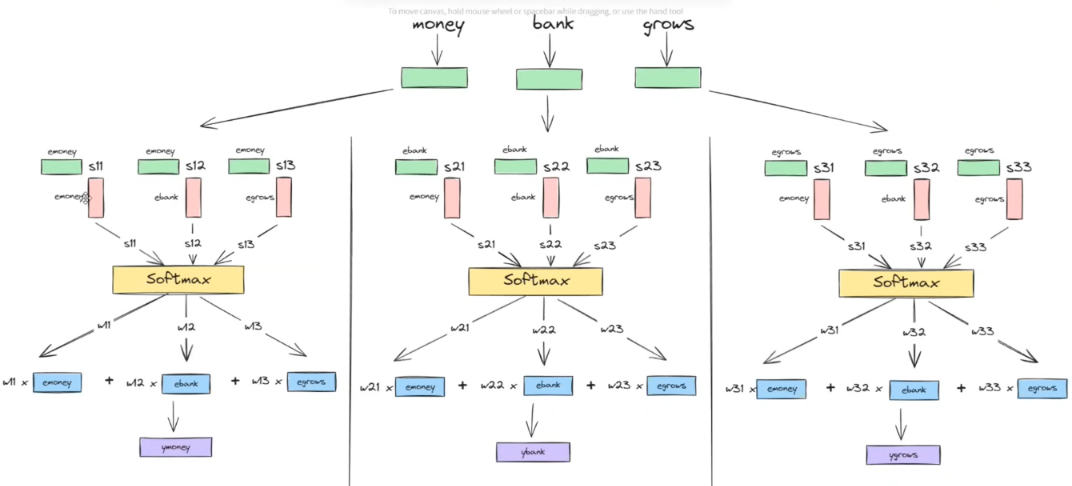

 Softmax converts a set of raw scores into probabilities/weights that add up to 1.

In self-attention, it's used to convert the Q·K similarity scores into attention weights.

Formula

For a score \(x_i\):

$$ softmax(x_i)=\frac{e^{x_i}}{\sum_j e^{x_j}} $$

The exponential \(e^x\) makes larger scores stand out more

When the dimension of Q and K is large, their dot products can become large. Feeding these large values directly into softmax can make it saturated, producing probabilities close to 0 or 1 and very small gradients. Therefore, we scale the scores by dividing by \(\sqrt{d_k}\) to keep the values in a manageable range and improve training stability

every process is parallel

Tokenizer assigns IDs → IDs are converted to vectors via Lookup Table → Each layer improves/modifies these vectors to capture better meaning and context.

task specific contextual embedding

The Q, K, and V weight matrices are initially randomly initialized. During training, backpropagation updates these weights to minimize the loss, allowing the model to learn useful Q, K, and V representations

problem with self attention is it give single perpective so we use multi attention where more than 1 self attention is used


when matrix is generated through more than 1 self attention we concatatnate them for multi head attention  Multi-head attention runs multiple attention heads in parallel, each with its own Q/K/V projections. Their outputs are concatenated and then passed through a final linear projection.

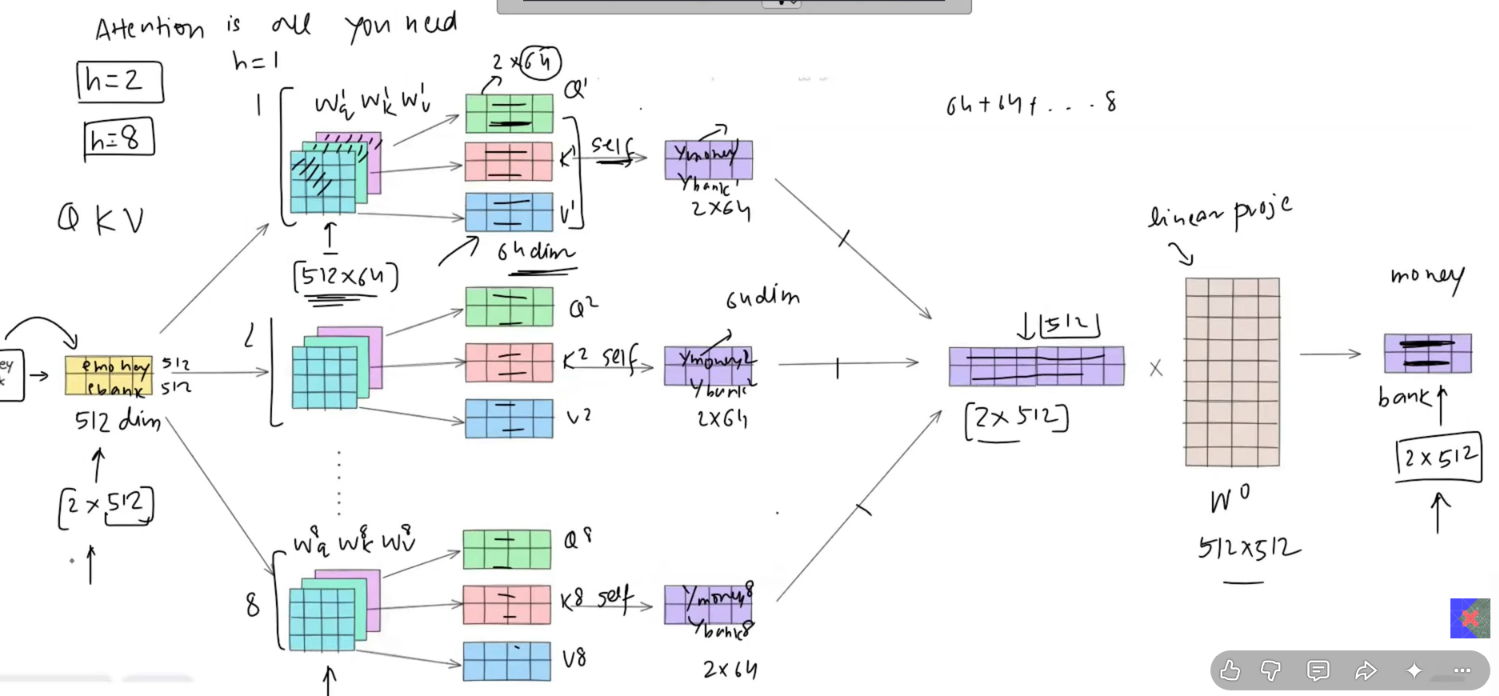

runnig parallel self attention for each word has problem we cannot decide ordering of word which can completly deflect meanig of sentence so positional encoding is introduced
Self-attention processes tokens in parallel and is permutation-equivariant, so it does not inherently encode the order of tokens. Positional information is therefore added to token representations so the Transformer can distinguish different token positions

In [ ]:
%pip install accelerate

In [ ]:
%pip install fugashi unidic_lite

In [ ]:

import torch
from transformers import AutoModel, AutoTokenizer

bertjapanese = AutoModel.from_pretrained("cl-tohoku/bert-base-japanese", device_map="auto")
tokenizer = AutoTokenizer.from_pretrained("cl-tohoku/bert-base-japanese")

## Input Japanese Text
line = "吾輩は猫である。"
inputs = tokenizer(line, return_tensors="pt").to(bertjapanese.device)

print(tokenizer.decode(inputs["input_ids"][0]))

outputs = bertjapanese(**inputs)